# 5 — Monte Carlo (model-free) po Dynamic Programming

**Cel:** Zrozumieć i zaimplementować:
- MC prediction: estymacja `Vπ` z epizodów,
- MC control (on-policy): uczenie `Q` i polityki przez ε-greedy.

**Dlaczego po Ch04?**  
W Ch04 liczyliśmy wartości z modelu `P[s][a]` (full backup).  
Tu uczymy się z epizodów (sample backup).

TODO: WSTAW RYSUNEK (Sutton): definicja returnu G_t + pseudokod MC prediction/control.


### Co się zmienia w Ch05 w porównaniu do Ch04?

W Ch04:
- znaliśmy pełny model środowiska `P[s][a]`,
- wartości liczyliśmy dokładnie (Dynamic Programming).

W Ch05:
- **udajemy, że modelu nie znamy**,
- widzimy tylko próbki trajektorii,
- uczymy się z danych (Monte Carlo),
- `V(s)` i `Q(s,a)` są estymatorami losowymi.

Ten rozdział odpowiada na pytanie:
> Jak uczyć się wartości, gdy jedyne co mamy, to doświadczenie?


# Ch05 — Przejście z Dynamic Programming do model-free Reinforcement Learning

Do tej pory (Ch04) rozwiązywaliśmy problemy RL w trybie **model-based**:
znaliśmy pełny model środowiska i liczyliśmy wartości dokładnie.

W Ch05 **zmieniamy paradygmat**.

Nie pytamy już:
> „Jakie są wszystkie możliwe przejścia i ich prawdopodobieństwa?”

Zamiast tego pytamy:
> „Co się faktycznie zdarzyło w doświadczeniu agenta?”

---

## Co oznacza „model-based” (Ch04)?

W Ch04 mieliśmy dostęp do:
- pełnego modelu `P[s][a]`,
- wszystkich możliwych przejść `(s,a) → (s',r)`.

Dlatego mogliśmy robić **full backup** (dokładne oczekiwanie):

V(s) = sum_a pi(a|s) sum_{s',r} p(s',r|s,a)[r + gamma V(s')]

W kodzie było to widoczne wprost:

```
for a in actions:
    for (p, s2, r, _) in P[s][a]:
        q += p * (r + gamma * V[s2])
```

To jest **dokładna wartość oczekiwana** — żadnej losowości, żadnej estymacji.

---

## Co zmienia się w Ch05?

W Ch05 **udajemy, że modelu nie znamy**.

Agent:
- nie widzi `P[s][a]`,
- nie zna prawdopodobieństw,
- **widzi tylko próbki** doświadczenia:

(s0, a0, r1, s1), (s1, a1, r2, s2), ...

Dlatego uczymy się z **epizodów**.

---

## Gdzie dokładnie w kodzie znika model?

Spójrz na metodę `step` środowiska:

```
class PModelEnv:
    def step(self, a):
        outcomes = self.P[self.s][a]
        idx = rng.choice(...)
        return s2, r, done
```

Algorytmy MC/TD **nie widzą `outcomes`** — dostają tylko jedną próbkę (s2, r).

---

## Monte Carlo (MC): uczymy się z pełnych epizodów

Monte Carlo **nie bootstrappuje**.
Czeka, aż epizod się skończy, i liczy **pełny zwrot (return)**:

G_t = R_{t+1} + gamma R_{t+2} + gamma^2 R_{t+3} + ...

W kodzie:

```
G = 0
for t in reversed(range(len(episode))):
    G = r + gamma * G
```

---

## Gdzie pojawia się wariancja?

Każdy epizod jest inny, szczególnie w środowisku `slippery=True`.

Widzimy to na wykresach:
- V(start) vs liczba epizodów,
- wiele seedów → duży rozrzut.

To **nowe zjawisko**, którego nie było w DP.

---

## MC control: uczymy się polityki z doświadczenia

W MC control:
- uczymy Q(s,a),
- polityka **nie jest dana z góry**,
- agent sam ją odkrywa.

Kluczowa linia:

```
a = epsilon_greedy_action(Q[s], eps)
```

---

## Dlaczego teraz potrzebujemy epsilon-greedy?

Bez eksploracji agent:
- nie zobaczy alternatywnych akcji,
- utknie w lokalnym zachowaniu.

epsilon-greedy to kompromis eksploracja/eksploatacja.

---

## Co dokładnie odróżnia Ch05 od projektu po Ch04?

Projekt Ch04:
- znamy model,
- brak wariancji,
- wartości dokładne.

Ch05:
- model ukryty,
- sample-based learning,
- wartości jako estymatory losowe.

---

## Co będzie dalej (Ch06)?

Monte Carlo:
- duża wariancja,
- brak bootstrapu.

Ch06:
- TD(0): bootstrap,
- SARSA (on-policy),
- Q-learning (off-policy).

---

## Podsumowanie

W Ch05 uczymy się wartości i polityki wyłącznie z doświadczenia, bez modelu — to pierwszy prawdziwy krok w stronę Reinforcement Learning.


## Plan (ok. 2–2.5h)

1) Setup środowiska i referencja z DP (VI)  
2) Ćwiczenie 1: MC prediction (first-visit)  
3) Eksperyment A: wpływ liczby epizodów i seedów na `V(start)`  
4) Ćwiczenie 2: MC control (on-policy, ε-greedy)  
5) Eksperyment B: det vs slippery + sweep po ε  
6) Krótki raport: 8–12 zdań wniosków


In [30]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from typing import Optional, Dict, List, Tuple

# ---------- Viz helpers (consistent with Ch04) ----------
def pretty_matrix_as_grid(v: np.ndarray, nrow: int, ncol: int, decimals: int = 2):
    grid = np.asarray(v, dtype=float).reshape(nrow, ncol)
    with np.printoptions(precision=decimals, suppress=True):
        print(grid)

def action_arrows(pi_det: np.ndarray, nrow: int, ncol: int, arrows: Dict[int, str]):
    out = []
    for r in range(nrow):
        row = []
        for c in range(ncol):
            s = r * ncol + c
            row.append(arrows.get(int(pi_det[s]), '?'))
        out.append(' '.join(row))
    print('\n'.join(out))

def moving_average(x, window: int = 200):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    w = np.ones(window) / window
    return np.convolve(x, w, mode="valid")

# ---------- Environment wrapper: sample transitions from P[s][a] ----------
class _Discrete:
    def __init__(self, n: int):
        self.n = int(n)

class PModelEnv:
    """Minimal env wrapper around model P[s][a]."""
    def __init__(self, P, start_state: int = 0, seed: int = 0):
        self.P = P
        self.nS = len(P)
        s0 = next(iter(P))
        self.nA = len(P[s0])
        self.action_space = _Discrete(self.nA)
        self.observation_space = _Discrete(self.nS)
        self.start_state = int(start_state)
        self.rng = np.random.default_rng(seed)
        self.s = self.start_state

    def reset(self, seed: Optional[int] = None):
        if seed is not None:
            self.rng = np.random.default_rng(int(seed))
        self.s = self.start_state
        return int(self.s), {}

    def step(self, a: int):
        a = int(a)
        outcomes = self.P[self.s][a]  # [(p, s2, r, terminated), ...]
        ps = np.array([o[0] for o in outcomes], dtype=float)
        idx = int(self.rng.choice(len(outcomes), p=ps/ps.sum()))
        p, s2, r, terminated = outcomes[idx]
        self.s = int(s2)
        return int(s2), float(r), bool(terminated), False, {}

# ---------- FrozenLake model builder (no Gym) ----------
def build_frozenlake_P(desc, is_slippery: bool = False):
    """FrozenLake in P[s][a] format. Actions: 0=L,1=D,2=R,3=U."""
    desc = np.asarray([list(row) for row in desc], dtype="<U1")
    nrow, ncol = desc.shape
    nS, nA = nrow * ncol, 4

    LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
    moves = {LEFT:(0,-1), DOWN:(1,0), RIGHT:(0,1), UP:(-1,0)}

    def to_s(r,c): return r*ncol+c
    def step_from(r,c,a):
        dr,dc = moves[a]
        r2,c2 = r+dr, c+dc
        if r2<0 or r2>=nrow or c2<0 or c2>=ncol:
            r2,c2 = r,c
        return r2,c2

    P = {s: {a: [] for a in range(nA)} for s in range(nS)}
    for r in range(nrow):
        for c in range(ncol):
            s = to_s(r,c)
            tile = desc[r,c]
            if tile in ("H","G"):
                for a in range(nA):
                    P[s][a] = [(1.0, s, 0.0, True)]
                continue

            for a in range(nA):
                if is_slippery:
                    candidates = [(a-1)%4, a, (a+1)%4]
                    probs = [1/3, 1/3, 1/3]
                else:
                    candidates = [a]
                    probs = [1.0]

                outcomes = []
                for a_real, p in zip(candidates, probs):
                    r2,c2 = step_from(r,c,a_real)
                    s2 = to_s(r2,c2)
                    tile2 = desc[r2,c2]
                    terminated = tile2 in ("H","G")
                    reward = 1.0 if tile2 == "G" else 0.0
                    outcomes.append((float(p), int(s2), float(reward), bool(terminated)))

                merged = {}
                for p, s2, rwd, term in outcomes:
                    key = (s2, rwd, term)
                    merged[key] = merged.get(key, 0.0) + p
                P[s][a] = [(p, s2, rwd, term) for (s2, rwd, term), p in merged.items()]
    return P, nS, nA, nrow, ncol, desc

# ---------- Shared env instances ----------
desc4 = ["SFFF","FHFH","FFFH","HFFG"]
P_fl_det, nS, nA, nrow, ncol, _ = build_frozenlake_P(desc4, is_slippery=False)
P_fl_slip, _, _, _, _, _ = build_frozenlake_P(desc4, is_slippery=True)

env = PModelEnv(P_fl_det, start_state=0, seed=0)
env_slip = PModelEnv(P_fl_slip, start_state=0, seed=0)

arrows_fl = {0:"←",1:"↓",2:"→",3:"↑"}

print("FrozenLake map:")
print("\\n".join(desc4))
print("n_states =", nS, "n_actions =", nA)


FrozenLake map:
SFFF\nFHFH\nFFFH\nHFFG
n_states = 16 n_actions = 4


In [8]:
desc4 = ["SFFF","FHFH","FFFH","HFFG"]
P_slip, nS, nA, nrow, ncol, _ = build_frozenlake_P(desc4, is_slippery=True)

RIGHT = 2
print("Model: P[0][RIGHT] =", P_slip[0][RIGHT])


Model: P[0][RIGHT] = [(0.3333333333333333, 4, 0.0, False), (0.3333333333333333, 1, 0.0, False), (0.3333333333333333, 0, 0.0, False)]


### Sanity check: `P[s][a]` (model) vs `PModelEnv.step()` (próbkowanie)

Ten test sprawdza, że `PModelEnv.step(a)` jest dokładnie **losowaniem jednej próbki** z rozkładu przejść zapisanego w `P[s][a]`.

Co robimy:
1. Tworzymy środowisko `env` z modelu `P_slip` (slippery) i ustawiamy seed losowości (powtarzalność).
2. W pętli `N` razy:
   - robimy `env.reset()` żeby **zawsze startować z tego samego stanu** (tu: `s=0`),
   - wykonujemy **jeden krok** tą samą akcją (tu: `RIGHT`),
   - zliczamy, do jakiego stanu `s2` trafiliśmy.
3. Dzieląc zliczenia przez `N` dostajemy empiryczne prawdopodobieństwa przejść.
   Dla dużego `N` powinny one być bliskie wartościom zapisanym w `P[0][RIGHT]` (prawo wielkich liczb).

W skrócie:
- `P[0][RIGHT]` mówi „jakie przejścia są możliwe i z jakimi prawdopodobieństwami”.
- `env.step(RIGHT)` losuje jedno z nich, a pętla pokazuje, że częstości z próbek zgadzają się z modelem.


In [29]:
env_test = PModelEnv(P_slip, start_state=0, seed=1)

N = 20000
counts = {}
for _ in range(N):
    env.reset()                 # zawsze wracamy do s=0
    s2, r, done, trunc, info = env_test.step(RIGHT)
    counts[s2] = counts.get(s2, 0) + 1

emp = {s: c/N for s, c in counts.items()}
print("Empiryczne prawdopodobieństwa:", emp)


Empiryczne prawdopodobieństwa: {1: 0.0001, 5: 0.9999}


### Slippery FrozenLake: jak losuje się „rzeczywista” akcja?

W trybie `is_slippery=True` agent wybiera akcję `a`, ale środowisko wykonuje jedną z trzech akcji:
- `(a-1) % 4`  — skręt „w lewo” (odchylenie o 90°)
- `a`          — ruch zgodny z intencją
- `(a+1) % 4`  — skręt „w prawo” (odchylenie o 90°)

W tej implementacji wszystkie trzy są jednakowo prawdopodobne: `1/3, 1/3, 1/3`.

Akcje kodujemy: `0=LEFT, 1=DOWN, 2=RIGHT, 3=UP`.

| Wybrana akcja `a` | Możliwe wykonane akcje (w slippery) |
|---:|---|
| LEFT (0)  | UP (3), LEFT (0), DOWN (1) |
| DOWN (1)  | LEFT (0), DOWN (1), RIGHT (2) |
| RIGHT (2) | DOWN (1), RIGHT (2), UP (3) |
| UP (3)    | RIGHT (2), UP (3), LEFT (0) |

Uwaga: jeśli wykonany ruch wychodzi poza planszę, agent zostaje w tym samym stanie (odbicie od ściany).


### Jak kodujemy stany?

Stan `s` to indeks pola w siatce 4×4, liczony wierszami:
$
s = r \cdot ncol + c
$
czyli `0` to lewy górny róg, `1` jest obok w prawo, `4` jest jedno pole w dół itd.

### Terminalność i nagroda

- Pola `H` (hole) i `G` (goal) są **terminalne** (`done=True`) i **absorbujące**:
  po wejściu w stan terminalny zostajemy w nim (nie ma dalszej dynamiki).
- Nagroda `+1` jest tylko za **wejście na `G`**, w pozostałych przypadkach `0`.
  To oznacza, że sygnał nagrody jest rzadki → MC ma dużą wariancję.


### Model `P[s][a]` vs środowisko `PModelEnv`

W tym kursie FrozenLake jest opisany **jawnie** jako model MDP:

$
P[s][a] = \{(p, s', r, done), ...\}
$

- `P[s][a]` to **pełna informacja**: wszystkie możliwe przejścia i ich prawdopodobieństwa.
- W **DP (Ch04)** aktualizacje wartości liczymy przez *wartość oczekiwaną* po `P[s][a]` (sumujemy po wszystkich outcomes).
- W **model-free (Ch05–06)** uczymy się z danych, więc potrzebujemy generatora doświadczeń.

`PModelEnv` to minimalny wrapper, który zamienia tabelę `P` w środowisko typu Gym (`reset/step`):
- `step(a)` bierze listę `P[s][a]` i **losuje jedno przejście** zgodnie z prawdopodobieństwami `p`.
- Po wielu wywołaniach `step` empiryczne częstości przejść zbliżają się do wartości w `P` (prawo wielkich liczb).

W skrócie:
- DP: **model → oczekiwanie → V/Q**
- MC/TD: **model → próbki (epizody) → estymator → V/Q**


**Interpretacja:** DP sumuje po wszystkich przejściach w `P[s][a]` (wartość oczekiwana), a MC/TD widzą tylko próbki generowane przez `step()` — dlatego potrzebujemy takiego wrappera.







### `terminated` vs `truncated` w tej implementacji

`PModelEnv.step()` zwraca `truncated=False`. Ograniczenie długości epizodu realizujemy w generatorach epizodów przez `max_steps`.
To jest odpowiednik „TimeLimit” z Gym, ale kontrolujemy go jawnie w kodzie.

### Dwa źródła losowości

1) **Środowisko (slippery)**: `step(a)` losuje przejście z rozkładu `P[s][a]`.
2) **Polityka (ε-greedy)**: czasem wybieramy losową akcję, żeby eksplorować.

W eksperymentach można porównywać:
- det + ε (losowość tylko z eksploracji)
- slip + ε (losowość z eksploracji i z dynamiki)


### DP reference (Value Iteration, powtórzenie): „złoty standard” do porównań w model-free 

Ten blok liczy **optymalną funkcję wartości** $v^*$ i wynikającą z niej **optymalną politykę deterministyczną** $pi^*$ dla naszego modelu `P[s][a]`.  
Używamy go jako **benchmarku/debug checku** w Ch05–06: krzywe MC/TD powinny (w miarę danych) zbliżać się do wyniku DP.

**`value_iteration(P, gamma, ...)`**:
- startuje od `v=0`,
- iteracyjnie wykonuje backup Bellmana dla optimum:
$
v(s) \leftarrow \max_a \sum_{s',r} p(s',r|s,a)\,[r + \gamma v(s')]
$
- kończy, gdy największa zmiana `delta` spadnie poniżej `theta`.

**`greedy_policy_from_v(P, v, gamma)`**:
- dla każdego stanu wybiera akcję, która maksymalizuje wartość oczekiwaną (tzw. one-step lookahead),
- zwraca politykę deterministyczną `pi_det[s] = argmax_a Q(s,a)` obliczone z `v`.

Na końcu liczymy DP osobno dla:
- wersji deterministycznej (`P_fl_det`),
- wersji śliskiej (`P_fl_slip`),

i wypisujemy `v*(start)` jako prostą metrykę jakości optymalnego rozwiązania.


In [11]:
# ---------- DP reference (Value Iteration) ----------
def greedy_policy_from_v(P, v: np.ndarray, gamma: float = 0.99) -> np.ndarray:
    nS = v.shape[0]
    s0 = next(iter(P))
    nA = len(P[s0])
    pi_det = np.zeros(nS, dtype=int)
    for s in range(nS):
        best_a = 0
        best_q = -np.inf
        for a in range(nA):
            q = 0.0
            for (p, s2, r, terminated) in P[s][a]:
                if terminated:
                    q += float(p) * float(r)
                else:
                    q += float(p) * (float(r) + gamma * float(v[int(s2)]))
            if q > best_q:
                best_q = q
                best_a = a
        pi_det[s] = best_a
    return pi_det

def value_iteration(P, gamma: float = 0.99, theta: float = 1e-10, max_iters: int = 100_000):
    nS = len(P)
    s0 = next(iter(P))
    nA = len(P[s0])
    v = np.zeros(nS, dtype=float)
    for _ in range(max_iters):
        delta = 0.0
        for s in range(nS):
            v_old = v[s]
            best_q = -np.inf
            for a in range(nA):
                q = 0.0
                for (p, s2, r, terminated) in P[s][a]:
                    if terminated:
                        q += float(p) * float(r)
                    else:
                        q += float(p) * (float(r) + gamma * float(v[int(s2)]))
                best_q = max(best_q, q)
            v[s] = best_q
            delta = max(delta, abs(v_old - v[s]))
        if delta < theta:
            break
    pi_det = greedy_policy_from_v(P, v, gamma=gamma)
    return pi_det, v

gamma = 0.99
pi_star_det, v_star_det = value_iteration(P_fl_det, gamma=gamma)
pi_star_slip, v_star_slip = value_iteration(P_fl_slip, gamma=gamma)

print("DP reference: v*(start) det =", float(v_star_det[0]), "| slip =", float(v_star_slip[0]))


DP reference: v*(start) det = 0.9509900498999999 | slip = 0.5420259308172148


### Common model-free helpers: eksploracja i generowanie epizodów

W model-free (MC/TD) nie liczymy wartości z równań jak w DP, tylko uczymy się z **danych**: epizodów zawierających przejścia `(s, a, r, s')`.  
Poniższe funkcje zapewniają dwa kluczowe elementy: **wybór akcji z eksploracją** oraz **generator epizodów**.

#### `epsilon_greedy_action(q_s, eps, rng)`
Wybór akcji metodą **ε-greedy** na podstawie wektora wartości `q_s = Q(s, :)`.

- z prawdopodobieństwem `eps` wybieramy **losową akcję** (eksploracja),
- z prawdopodobieństwem `1 - eps` wybieramy `argmax_a Q(s,a)` (eksploatacja).

To jest standardowy mechanizm, który zapobiega „utknięciu” w słabej polityce.

#### `generate_episode_det_policy(env, pi_det, ...)`
Generuje jeden epizod w środowisku, wykonując **deterministyczną politykę** `pi_det`.

- start: `reset()` (opcjonalnie z `seed`),
- w każdym kroku: `a = pi_det[s]`,
- zapisujemy trójki `(s, a, r)` do listy `episode`,
- kończymy po osiągnięciu stanu terminalnego (`done=True`) albo po `max_steps`.

Zastosowanie: np. **MC prediction** (estymacja \(V^\pi\) dla zadanej polityki).

#### `generate_episode_eps_greedy(env, Q, eps, rng, ...)`
Generuje epizod, gdy polityka jest **ε-greedy względem aktualnego Q**.

- start: `reset()`,
- w każdym kroku: `a = epsilon_greedy_action(Q[s], eps, rng)`,
- zapisujemy `(s, a, r)` do listy `episode`,
- kończymy na terminalu lub po `max_steps`.

Zastosowanie: **control** (uczenie \(Q\) i polityki), np. MC control / SARSA / Q-learning.

> Uwaga: `max_steps` pełni rolę ograniczenia długości epizodu (nasz „time limit”), niezależnie od tego, czy środowisko ma naturalny stan terminalny.


In [13]:
# ---------- Common model-free helpers ----------
def epsilon_greedy_action(q_s: np.ndarray, eps: float, rng: np.random.Generator) -> int:
    if rng.random() < eps:
        return int(rng.integers(0, len(q_s)))
    return int(np.argmax(q_s))

def generate_episode_det_policy(env: PModelEnv, pi_det: np.ndarray,
                                max_steps: int = 200, seed: Optional[int] = None):
    s, _ = env.reset(seed=seed)
    episode = []
    for _ in range(max_steps):
        a = int(pi_det[s])
        s2, r, done, trunc, _ = env.step(a)
        episode.append((s, a, r))
        if done or trunc:
            break
        s = s2
    return episode

def generate_episode_eps_greedy(env: PModelEnv, Q: np.ndarray, eps: float,
                                rng: np.random.Generator, max_steps: int = 200):
    s, _ = env.reset()
    episode = []
    for _ in range(max_steps):
        a = epsilon_greedy_action(Q[s], eps, rng)
        s2, r, done, trunc, _ = env.step(a)
        episode.append((s, a, r))
        if done or trunc:
            break
        s = s2
    return episode


### Po co ε-greedy? (intuicja)

W model-free uczymy się tylko z trajektorii, które faktycznie wygenerujemy.
Jeśli polityka jest czysto zachłanna (ε=0) i startujemy od Q=0, to `argmax` wybiera zawsze tę samą akcję (np. 0),
przez co agent może chodzić w kółko i nigdy nie odkryć ścieżki do celu.

ε-greedy wymusza eksplorację: czasem wybieramy losową akcję, dzięki czemu:
- odwiedzamy więcej stanów,
- uczymy się wartości różnych akcji,
- mamy szansę trafić do celu i „rozszerzyć” sygnał nagrody na wcześniejsze stany.


## Testy środowiska

### Test „coverage”: dlaczego potrzebujemy ε-greedy?

Poniższy fragment nie „uczy” jeszcze żadnego algorytmu MC/TD.  
On tylko sprawdza, **jakie dane agent w ogóle jest w stanie zebrać** przy danym poziomie eksploracji `eps`.

#### Co robi `rollout_stats(...)`?

Funkcja uruchamia wiele epizodów i mierzy trzy rzeczy:

1) **`unique_states`** – ile różnych stanów agent odwiedził łącznie  
   (czy agent „widzi” znaczną część planszy czy utknął w małym obszarze).

2) **`unique_state_actions`** – ile różnych par `(s,a)` agent wykonał łącznie  
   (czy agent testuje różne akcje w różnych stanach, czy powtarza jeden schemat).

3) **`success_rate`** – odsetek epizodów zakończonych sukcesem  
   (tu: sukces = ostatnia nagroda `1.0`, czyli wejście na pole `G`).

Mechanika w środku:
- `generate_episode_eps_greedy(...)` generuje jeden epizod, gdzie akcje wybierane są ε-greedy względem `Q`.
- Po epizodzie:
  - jeśli ostatnia nagroda wynosi `1.0`, liczymy sukces,
  - dodajemy wszystkie odwiedzone stany i pary `(s,a)` do zbiorów (sety usuwają duplikaty).

Na końcu zwracamy słownik z metrykami.

#### Dlaczego porównujemy `eps=0.0` i `eps=0.1`?

- Przy `eps=0.0` agent jest w 100% zachłanny (`argmax Q`), a dla startowego `Q0=0` wszystkie akcje są remisowe.
  `argmax` rozstrzyga remis zawsze wybierając pierwszy indeks → agent wybiera stale tę samą akcję (często `0=LEFT`),
  co może powodować utknięcie (np. w rogu planszy) i bardzo małe pokrycie stanów.

- Przy `eps=0.1` w 10% kroków agent wybiera losową akcję, więc:
  - odwiedza więcej stanów,
  - wykonuje więcej różnych `(s,a)`,
  - ma większą szansę „odkryć” drogę do celu (a dopiero wtedy MC/TD ma sygnał do uczenia).

#### Jak to wiąże się z konstrukcją `env`?

`env` (klasa `PModelEnv`) jest **samplerem** z modelu `P[s][a]`:
- `env.step(a)` losuje jedno przejście `(s', r, done)` z listy `P[s][a]` zgodnie z prawdopodobieństwami `p`.
W trybie `slippery` dodatkowa losowość pochodzi też z tego, że „zamierzona” akcja może zostać zrealizowana jako
`(a-1)%4`, `a` lub `(a+1)%4`.

W tym teście interesuje nas przede wszystkim losowość po stronie **polityki** (ε-greedy), czyli czy agent w ogóle próbuje
różnych akcji — bo bez tego nie ma danych, a bez danych nie ma uczenia.


In [14]:
def rollout_stats(env, Q, eps, rng, episodes=500, max_steps=200):
    visited_states = set()
    visited_sa = set()
    successes = 0

    for _ in range(episodes):
        ep = generate_episode_eps_greedy(env, Q, eps, rng, max_steps=max_steps)
        # sukces = ostatnia nagroda 1 (wejście na G)
        if len(ep) > 0 and ep[-1][2] == 1.0:
            successes += 1
        for (s,a,r) in ep:
            visited_states.add(int(s))
            visited_sa.add((int(s), int(a)))

    return {
        "episodes": episodes,
        "unique_states": len(visited_states),
        "unique_state_actions": len(visited_sa),
        "success_rate": successes / episodes
    }

# Porównanie: eps=0 (brak eksploracji) vs eps=0.1
rng1 = np.random.default_rng(0)
rng2 = np.random.default_rng(0)

Q0 = np.zeros((nS, nA), dtype=float)   # typowy start w MC/TD

print("eps=0.0:", rollout_stats(env_slip, Q0, eps=0.0, rng=rng1, episodes=500))
print("eps=0.1:", rollout_stats(env_slip, Q0, eps=0.1, rng=rng2, episodes=500))


eps=0.0: {'episodes': 500, 'unique_states': 3, 'unique_state_actions': 3, 'success_rate': 0.0}
eps=0.1: {'episodes': 500, 'unique_states': 8, 'unique_state_actions': 23, 'success_rate': 0.0}


## Pokazujemy różnicę w odwiedzonych stanach dla eps = 0 lub 0.1

In [20]:
# szybki debug: konkretne stany
def rollout_states(env, Q, eps, rng, episodes=50, max_steps=200):
    visited_states = set()
    for _ in range(episodes):
        ep = generate_episode_eps_greedy(env, Q, eps, rng, max_steps=max_steps)
        for (s,a,r) in ep:
            visited_states.add(int(s))
    return sorted(visited_states)

print(rollout_states(env_slip, Q0, eps=0.0, rng=np.random.default_rng(0), episodes=200))
print(rollout_states(env_slip, Q0, eps=0.1, rng=np.random.default_rng(0), episodes=200))


[0, 4, 8]
[0, 1, 2, 4, 6, 8, 9, 13]


In [15]:
Q0 = np.zeros((nS, nA))
print("argmax(Q0[s]) =", np.argmax(Q0[0]))  # zwykle 0


argmax(Q0[s]) = 0


---

## 1) MC prediction (first-visit)

**Idea:** liczymy `Vπ` jako średnią zwrotów (returnów) obserwowanych w epizodach:

$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$

**First-visit:** w jednym epizodzie aktualizujemy stan `s` tylko przy jego pierwszym wystąpieniu.

### Ćwiczenie 1 — implementacja MC prediction
Zaimplementuj funkcję `mc_prediction_first_visit(...)`.

Wymagania:
- licz `G` od końca epizodu,
- first-visit (np. set visited),
- aktualizacja średnią inkrementalną.

Wskazówka: `V[s] += (G - V[s]) / N[s]`.


## MC prediction (first-visit) — estymacja $V^\pi$

Cel: oszacować wartość stanów $V^\pi(s)$ dla **zadanej polityki** $\pi$, używając tylko epizodów.

**Idea Monte Carlo:**
- generujemy pełny epizod zgodnie z $\pi$,
- liczymy return:
$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots
$
- aktualizujemy $V(s)$ jako średnią z obserwowanych returnów.

**First-visit MC:**
dla danego epizodu aktualizujemy stan `s` tylko przy **pierwszej wizycie** (żeby nie „nadważać” tego samego epizodu).

**Technicznie w kodzie:**
- przechodzimy po epizodzie od końca i kumulujemy `G`,
- `visited` pilnuje first-visit,
- `V[s] += (G - V[s]) / N[s]` to średnia inkrementalna (bez trzymania wszystkich próbek).


In [21]:
def mc_prediction_first_visit(env: PModelEnv, pi_det: np.ndarray,
                              gamma: float = 0.99, episodes: int = 20_000,
                              seed: int = 0, max_steps: int = 200):
    # TODO (STUDENT): Zaimplementuj MC first-visit prediction.
    # 1) V = zeros(nS), N = zeros(nS)
    # 2) for ep:
    #    - episode = generate_episode_det_policy(...)
    #    - G = 0; visited=set()
    #    - for t reversed:
    #        G = r + gamma*G
    #        if s not visited: update V[s] with incremental mean
    nS = env.observation_space.n
    V = np.zeros(nS, dtype=float)
    N = np.zeros(nS, dtype=int)
    rng = np.random.default_rng(seed)

    for _ in range(episodes):
        ep_seed = int(rng.integers(0, 10_000_000))
        ep = generate_episode_det_policy(env, pi_det, max_steps=max_steps, seed=ep_seed)
        G = 0.0
        visited = set()
        for t in reversed(range(len(ep))):
            s, a, r = ep[t]
            G = float(r) + gamma * G
            if s in visited:
                continue
            visited.add(s)
            N[s] += 1
            V[s] += (G - V[s]) / N[s]
    return V


### Demo: MC prediction dla π* (det) vs DP

To jest demo, ale studenci powinni umieć skomentować różnice (wariancja, liczba epizodów).


### Demo: MC prediction vs DP (benchmark)

Porównujemy:
- $V^\pi$ z MC (estymator z danych),
- $V^*$ z DP (wynik „dokładny” dla modelu).

To pokazuje dwie rzeczy:
1) MC zbliża się do DP przy dużej liczbie epizodów,
2) MC ma wariancję — wyniki zależą od losowości epizodów (szczególnie przy rzadkiej nagrodzie).


In [35]:
gamma = 0.99
V_mc = mc_prediction_first_visit(env, pi_star_det, gamma=gamma, episodes=30_000, seed=0)

print("MC V_pi (pi* det):")
pretty_matrix_as_grid(V_mc, nrow, ncol, decimals=2)

print("\nDP V* (det):")
pretty_matrix_as_grid(v_star_det, nrow, ncol, decimals=2)

print("\nmax |MC - DP| =", float(np.max(np.abs(V_mc - v_star_det))))
print("V(start) MC =", float(V_mc[0]), "| DP =", float(v_star_det[0]))


MC V_pi (pi* det):
[[0.95 0.   0.   0.  ]
 [0.96 0.   0.   0.  ]
 [0.97 0.98 0.   0.  ]
 [0.   0.99 1.   0.  ]]

DP V* (det):
[[0.95 0.96 0.97 0.96]
 [0.96 0.   0.98 0.  ]
 [0.97 0.98 0.99 0.  ]
 [0.   0.99 1.   0.  ]]

max |MC - DP| = 0.99
V(start) MC = 0.9509900498999999 | DP = 0.9509900498999999


**Uwaga (ważne):** MC prediction estymuje $V^\pi(s)$ tylko dla stanów, które są faktycznie odwiedzane w generowanych epizodach.
Ponieważ startujemy zawsze z `start_state=0` i używamy deterministycznej polityki $\pi^*$ w deterministycznym środowisku,
agent przechodzi prawie zawsze tą samą ścieżką do celu. Stany poza tą ścieżką nie są odwiedzane → ich wartości w MC pozostają równe 0.
Dlatego `V(start)` może zgadzać się idealnie z DP, mimo że `max|MC-DP|` jest duże.


## Jak uczciwie porównać MC z DP?

DP liczy $V(s)$ dla wszystkich stanów, bo zna model.  
MC estymuje $V(s)$ tylko dla stanów, które faktycznie odwiedzi w epizodach.

Dlatego porównujemy MC z DP na dwa sposoby:
1) **V(start)** — zawsze odwiedzany, więc to najważniejszy benchmark (tu: zgadza się idealnie).
2) **Błąd tylko na odwiedzonych stanach** (`N[s] > 0`) — inaczej stany nieodwiedzone mają wartość 0 „z braku danych”, co sztucznie zawyża błąd.


## Opcja 2 (bonus): więcej pokrycia stanów przez lekką eksplorację

W MC prediction wartości \(V(s)\) pojawiają się tylko dla stanów, które odwiedzimy.
Jeśli polityka jest deterministyczna (np. $\pi^*$ w det), trajektoria jest prawie zawsze ta sama → wiele stanów pozostaje nieoszacowanych.

Dlatego jako demonstrację robimy ewaluację „miękkiej” polityki:
- z prawdopodobieństwem $1-\varepsilon$ wybieramy akcję z $\pi^*$,
- z prawdopodobieństwem $\varepsilon$ wybieramy akcję losową.

To zwiększa liczbę odwiedzonych stanów (coverage), ale obniża wartość startową (bo czasem popełniamy „błędy”).


In [38]:
def generate_episode_eps_soft_pi(env: PModelEnv, pi_det: np.ndarray, eps: float,
                                 rng: np.random.Generator, max_steps: int = 200):
    """Epizod z polityki epsilon-soft wokół pi_det: (1-eps) pi_det, eps losowo."""
    s, _ = env.reset()
    episode = []
    nA = env.action_space.n
    for _ in range(max_steps):
        if rng.random() < eps:
            a = int(rng.integers(0, nA))
        else:
            a = int(pi_det[s])
        s2, r, done, trunc, _ = env.step(a)
        episode.append((s, a, r))
        if done or trunc:
            break
        s = s2
    return episode

def mc_prediction_first_visit_from_generator(gen_episode_fn, nS: int, episodes: int, gamma: float):
    """MC prediction FV, ale epizody dostajemy z przekazanego generatora."""
    V = np.zeros(nS, dtype=float)
    N = np.zeros(nS, dtype=int)
    for _ in range(episodes):
        ep = gen_episode_fn()
        G = 0.0
        visited = set()
        for (s,a,r) in reversed(ep):
            G = float(r) + gamma * G
            if s not in visited:
                visited.add(s)
                N[s] += 1
                V[s] += (G - V[s]) / N[s]
    return V, N

# --- demo: eps-soft wokół pi* ---
gamma = 0.99
episodes = 5000
eps_soft = 0.05
rng = np.random.default_rng(0)

V_soft, N_soft = mc_prediction_first_visit_from_generator(
    gen_episode_fn=lambda: generate_episode_eps_soft_pi(env, pi_star_det, eps_soft, rng, max_steps=200),
    nS=nS, episodes=episodes, gamma=gamma
)

coverage = (N_soft > 0).mean()
max_err_on_visited = np.max(np.abs(V_soft[N_soft > 0] - v_star_det[N_soft > 0]))

print(f"eps-soft={eps_soft}, episodes={episodes}")
print(f"coverage (visited states %) = {100*coverage:.1f}%")
print(f"V(start) MC_soft = {V_soft[0]:.4f} | DP* (det) = {v_star_det[0]:.4f}")
print(f"max |MC_soft - DP*| on visited = {max_err_on_visited:.4f}")


eps-soft=0.05, episodes=5000
coverage (visited states %) = 68.8%
V(start) MC_soft = 0.9007 | DP* (det) = 0.9510
max |MC_soft - DP*| on visited = 0.0508


---

## Eksperyment A (run & interpret): Jak rośnie jakość estymacji vs liczba epizodów?

**Cel:** pokazać wariancję MC i wpływ liczby epizodów.

Zadanie:
- policz `V(start)` dla rosnącej liczby epizodów,
- powtórz dla kilku seedów,
- narysuj wykres: epizody → `V(start)` (dla kilku seedów).

Wnioski: 4–6 zdań.


### Eksperyment A: wariancja MC

Rysujemy $V(\text{start})$ jako funkcję liczby epizodów dla wielu seedów.
To jest praktyczna demonstracja, że MC to estymator z danych:
- im więcej epizodów, tym stabilniej,
- ale przy małej liczbie epizodów wyniki mogą mocno „pływać”.


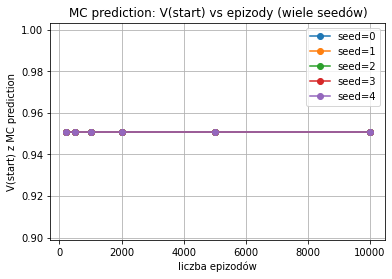

DP V*(start) = 0.9509900498999999


In [39]:
gammas = 0.99
episode_list = [200, 500, 1_000, 2_000, 5_000, 10_000]
seeds = [0, 1, 2, 3, 4]

vals = {sd: [] for sd in seeds}
for sd in seeds:
    for E in episode_list:
        V = mc_prediction_first_visit(env, pi_star_det, gamma=gamma, episodes=E, seed=sd)
        vals[sd].append(float(V[0]))

plt.figure()
for sd in seeds:
    plt.plot(episode_list, vals[sd], marker="o", label=f"seed={sd}")
plt.xlabel("liczba epizodów")
plt.ylabel("V(start) z MC prediction")
plt.title("MC prediction: V(start) vs epizody (wiele seedów)")
plt.grid(True)
plt.legend()
plt.show()

print("DP V*(start) =", float(v_star_det[0]))


---

## 2) MC control (on-policy, first-visit)

**Idea:** uczymy `Q(s,a)` z epizodów generowanych ε-greedy względem Q.  
Na końcu bierzemy politykę deterministyczną do wizualizacji: `pi_det = argmax_a Q(s,a)`.

### Ćwiczenie 2 — implementacja MC control

Zaimplementuj `mc_control_on_policy(...)`, które zwraca:
- `Q`,
- `pi` (deterministyczna do strzałek),
- `success_curve` (0/1 czy epizod zakończył się sukcesem).

Wskazówki:
- first-visit update dla (s,a),
- return `G` liczony od końca epizodu,
- średnia inkrementalna na `N[s,a]`.


## MC control (on-policy, first-visit) — uczenie \(Q\) i polityki

Cel: nauczyć się \(Q(s,a)\) i pośrednio polityki, **bez modelu**, z epizodów.

**On-policy** oznacza:
- epizody generujemy polityką, którą aktualnie mamy,
- w praktyce: **ε-greedy względem aktualnego \(Q\)**.

**First-visit update dla (s,a):**
- generujemy epizod ε-greedy,
- liczymy returny `G` od końca,
- aktualizujemy \(Q(s,a)\) tylko dla pierwszej wizyty `(s,a)` w epizodzie,
- używamy średniej inkrementalnej na `N[s,a]`.

**`success_curve`:**
zapisujemy 1, jeśli epizod trafił do celu (pojawiła się nagroda 1), inaczej 0.
To daje prostą krzywą uczenia: „jak często osiągamy cel”.


In [40]:
def mc_control_on_policy(env: PModelEnv,
                         gamma: float = 0.99, episodes: int = 50_000,
                         eps: float = 0.2, seed: int = 0, max_steps: int = 200):
    # TODO (STUDENT): Zaimplementuj MC control (on-policy) w wersji first-visit.
    # 1) Q = zeros((nS,nA)), N = zeros((nS,nA))
    # 2) for ep:
    #    - ep = generate_episode_eps_greedy(env, Q, eps, rng)
    #    - success_curve.append(1 if any(r>0) else 0)
    #    - G backward, visited set for (s,a), incremental mean update of Q[s,a]
    nS = env.observation_space.n
    nA = env.action_space.n
    Q = np.zeros((nS, nA), dtype=float)
    N = np.zeros((nS, nA), dtype=int)
    rng = np.random.default_rng(seed)
    success_curve = []

    for _ in range(episodes):
        ep = generate_episode_eps_greedy(env, Q, eps, rng, max_steps=max_steps)
        success_curve.append(1 if any(r > 0 for (_, _, r) in ep) else 0)

        G = 0.0
        visited = set()
        for t in reversed(range(len(ep))):
            s, a, r = ep[t]
            G = float(r) + gamma * G
            key = (s, a)
            if key in visited:
                continue
            visited.add(key)
            N[s, a] += 1
            Q[s, a] += (G - Q[s, a]) / N[s, a]

    pi_det = np.argmax(Q, axis=1).astype(int)
    return {"Q": Q, "pi": pi_det, "success_curve": np.asarray(success_curve, dtype=int)}


### Demo: MC control (det) — learning curve + polityka

- wykres `success_curve` (wygładzony moving average) pokazuje, czy agent uczy się trafiać do celu,
- `pi = argmax_a Q(s,a)` daje deterministyczną politykę do wizualizacji strzałkami.


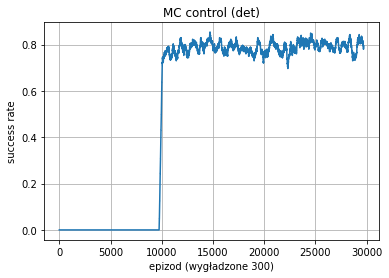

Policy learned (det):
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


In [41]:
out_det = mc_control_on_policy(env, gamma=0.99, episodes=30_000, eps=0.2, seed=0)

plt.figure()
plt.plot(moving_average(out_det["success_curve"], 300))
plt.xlabel("epizod (wygładzone 300)")
plt.ylabel("success rate")
plt.title("MC control (det)")
plt.grid(True)
plt.show()

print("Policy learned (det):")
action_arrows(out_det["pi"], nrow, ncol, arrows_fl)


---

## Eksperyment B (run & interpret): det vs slippery + sweep po ε

Zadanie:
1) Uruchom MC control na `env` i `env_slip`.
2) Porównaj krzywe sukcesu.
3) Zrób sweep po ε (np. `[0.05, 0.1, 0.2, 0.3]`) i porównaj końcowy success rate.

Wnioski: 6–10 zdań.


Porównujemy końcowy success rate dla różnych wartości ε.

Intuicja:
- za małe ε → zbyt mało eksploracji (łatwo utknąć),
- za duże ε → za dużo losowości (trudno „dowlec” się konsekwentnie do celu),
- w slippery często potrzeba innego „sweet spot” niż w det.


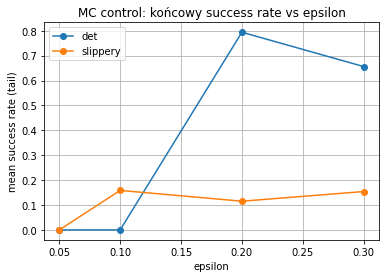

det: [(0.05, 0.0), (0.1, 0.0), (0.2, 0.794), (0.3, 0.6562)]
slip: [(0.05, 0.0), (0.1, 0.1587), (0.2, 0.1153), (0.3, 0.1542)]


In [42]:
eps_list = [0.05, 0.1, 0.2, 0.3]
episodes_det = 30_000
episodes_slip = 60_000

final_det = []
final_slip = []

for eps in eps_list:
    out1 = mc_control_on_policy(env, gamma=0.99, episodes=episodes_det, eps=eps, seed=0)
    out2 = mc_control_on_policy(env_slip, gamma=0.99, episodes=episodes_slip, eps=eps, seed=1)

    final_det.append(float(np.mean(out1["success_curve"][-5000:])))
    final_slip.append(float(np.mean(out2["success_curve"][-10000:])))

plt.figure()
plt.plot(eps_list, final_det, marker="o", label="det")
plt.plot(eps_list, final_slip, marker="o", label="slippery")
plt.xlabel("epsilon")
plt.ylabel("mean success rate (tail)")
plt.title("MC control: końcowy success rate vs epsilon")
plt.grid(True)
plt.legend()
plt.show()

print("det:", list(zip(eps_list, final_det)))
print("slip:", list(zip(eps_list, final_slip)))


---

## Oddanie (krótko)

Napisz 8–12 zdań wniosków:
1) Jak rośnie jakość `V(start)` w MC prediction wraz z liczbą epizodów i seedami?  
2) Jak ε wpływa na MC control (det vs slippery)?  
3) Jak porównałbyś MC z DP: zalety/wady? (wariancja, brak modelu)
